# Speed dating prediction
## Part 1 - Classification

In [ ]:
# library import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn import tree

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)
import pydotplus
from IPython.display import Image
import shap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Team identification



*   seminar SB M15 Monday 16:15 - 17:45
*   Team Speed Dating
*   Team members: Anna Ryglová, Martin Samaš, Martin Snížek, Jitka Šálková, Viktorie Švorcová

# Introduction

### The business value of predicting romantic compatibility
The business value of predicting romantic compatibility lies in transforming dating platforms from simple search engines, relying only on age range, location and stated preferences, to complex predictive tools that take into account many variables such as interests, field of study etc. The services can significantly increase user retention by offering profiles with higher probability of match by filtering information which is really important to people. We find implementing a machine learning classifier to predict a match highly interesting to explore.

###Link to the source of the data:
 https://www.openml.org/search?type=data&status=active&qualities.NumberOfClasses=%3D_2&id=40536&

### A brief description of the dataset
**Speed dating dataset (OpenML #40536)**

**authors**: Ray Fisman and Sheena Iyengar, Columbia Business School

8 378 rows

Data was collected from 21 experimental speed dating events at Columbia University during the years 2002-2004.

Each event consists of a four-minute first date of two people of opposite sex. After the date, both participants recorded whether they wanted to see the other participant again. (both yes = 1 = match) The participants complete questionnaires before (preferences, demographics and lifestyle), during (rating of a partner) and after the event (reflections and follow-up preferences.)

The questionnaires were not mandatory which causes a proportion of missing values.

The ratings and preferences are completely subjective which can cause a bias.

The dataset is divided into multiple key parts:


*   **Demographics** - age, race, zip code, income, career, field of study
*   **Rating of a partner** - rating each "partner" 1-10 in attractiveness, sincerity, intelligence, fun, ambition, shared interests, overall like
* **Preferences** - importance of values already mentioned in rating of a partner while dating as well as self-perception ratings of the same values
* **Lifestyle** - Intensity of interest in 17 different activities such as hiking, reading, music or yoga as well as dating habits









## Customization

**target attribute** - match
* a binary variable
* Would you like to see this person again?
* 1 = both participants said yes
* 0 = at least one participant said no

**instance of interest** - participant with iid 11
* we will use this participant to examine how the classifier scores and to illustrate model predictions at the row level

**attribute of interest** - Attractivness rating of the participant
* attractive_partner = from 0 to 10
* this attribute is highly influential in the model


**subset of rows interest** - Attractivness rating of the participant across all values
* we will compare if pair matches across the range of values

**cost matrix**

| | Predicted: 0 (No Match) | Predicted: 1 (Match) |
|---|:---:|:---:|
| **Actual: 0 (No Match)** | 0 (TN) | 1 (FP) |
| **Actual: 1 (Match)** | 2 (FN) | 0 (TP) |

| Decision | Outcome | Reasoning | Assigned Cost |
|---|---|---|:---:|
| **TP** | Predicted match → actual match | Correct prediction — no penalty, used as baseline | **0** |
| **TN** | Predicted no match → actual no match | Correct prediction — same baseline | **0** |
| **FP** | Predicted match → actual no match | A match is suggested that never materialises; wastes time and raises false hopes, but the error is recoverable | **1** |
| **FN** | Predicted no match → actual match | A genuine mutual connection is missed entirely and never pursued — the worst possible outcome | **2** |

* the cost matrix will help us select threshold correctly
* The cost matrix is based on our subjective reasoning. We assigned a cost of 2 to FN because missing a genuine connection is more costly than a wasted date. For this reason, we assigned a higher cost to FN than to FP.

## Dataset to dataframe

We transform dataset to dataframe fetching directly from OpenML platform. We also add the *iid* so we can later identify each row uniquely.

In [ ]:
dataset = fetch_openml(data_id=40536, as_frame=True, parser="auto")

X = dataset.data
y = dataset.target
df = pd.concat([X, y], axis=1)
df['iid'] = df.index

## Dataset description

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

print("### DataFrame Info")
df.info(verbose=True, show_counts=True)

print("\n### Summary Statistics")
display(df.describe(include='all'))

print("\n### First 5 Rows")
display(df.head())

### DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 122 columns):
 #    Column                           Non-Null Count  Dtype   
---   ------                           --------------  -----   
 0    has_null                         8378 non-null   category
 1    wave                             8378 non-null   int64   
 2    gender                           8378 non-null   category
 3    age                              8283 non-null   float64 
 4    age_o                            8274 non-null   float64 
 5    d_age                            8378 non-null   int64   
 6    d_d_age                          8378 non-null   category
 7    race                             8315 non-null   category
 8    race_o                           8305 non-null   category
 9    samerace                         8378 non-null   category
 10   importance_same_race             8299 non-null   float64 
 11   importance_same_religion         82

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,importance_same_race,importance_same_religion,d_importance_same_race,d_importance_same_religion,field,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,d_pref_o_attractive,d_pref_o_sincere,d_pref_o_intelligence,d_pref_o_funny,d_pref_o_ambitious,d_pref_o_shared_interests,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,d_attractive_o,d_sinsere_o,d_intelligence_o,d_funny_o,d_ambitous_o,d_shared_interests_o,attractive_important,sincere_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,d_attractive_important,d_sincere_important,d_intellicence_important,d_funny_important,d_ambtition_important,d_shared_interests_important,attractive,sincere,intelligence,funny,ambition,d_attractive,d_sincere,d_intelligence,d_funny,d_ambition,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,d_attractive_partner,d_sincere_partner,d_intelligence_partner,d_funny_partner,d_ambition_partner,d_shared_interests_partner,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,d_sports,d_tvsports,d_exercise,d_dining,d_museums,d_art,d_hiking,d_gaming,d_clubbing,d_reading,d_tv,d_theater,d_movies,d_concerts,d_music,d_shopping,d_yoga,interests_correlate,d_interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match,iid
count,8378,8378.000000,8378,8283.000000,8274.000000,8378.000000,8378,8315,8305,8378,8299.000000,8299.000000,8378,8378,8315,8289.000000,8289.000000,8289.000000,8280.000000,8271.000000,8249.000000,8378,8378,8378,8378,8378,8378,8166.000000,8091.000000,8072.000000,8018.000000,7656.000000,7302.000000,8378,8378,8378,8378,8378,8378,8299.000000,8299.000000,8299.000000,8289.000000,8279.000000,8257.000000,8378,8378,8378,8378,8378,8378,8273.000000,8273.000000,8273.000000,8273.000000,8273.000000,8378,8378,8378,8378,8378,8176.000000,8101.000000,8082.000000,8028.000000,7666.000000,7311.000000,8378,8378,8378,8378,8378,8378,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8378,8378,8378,8378,8378,8378,8378,8378,8378,8378,8378,8378,8378,8378,8378,8378,8378,8220.000000,8378,8277.000000,1800.000000,7205.000000,8378,8378,8378,8138.000000,8069.000000,8378,8378,8003.000000,8378,8378.000000
unique,2,NaN,2,NaN,NaN,NaN,4,5,5,2,NaN,NaN,3,3,259,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,3,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,3,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,3,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,NaN,3,NaN,NaN,NaN,3,3,3,NaN,NaN,3,3,NaN,2,NaN
top,1,NaN,male,NaN,NaN,NaN,[2-3],European/Caucasian-American,European/Caucasian-American,0,NaN,NaN,[2-5],[0-1],Business,NaN,NaN,NaN,NaN,NaN,NaN,[21-100],[16-20],[16-20],[16-20],[0-15],[0-15],NaN,NaN,NaN,NaN,NaN,NaN,[6-8],[6-8],[6-8],[6-8],[6-8],[0-5],NaN,NaN,NaN,NaN,NaN,NaN,[21-100],[16-20],[16-20],[16-20],[0-15],[0-15],NaN,NaN,NaN,NaN,NaN,[6-8],[9-10],[6-8],[6-8],[6-8],NaN,NaN,NaN,NaN,NaN,NaN,[6-8],[6-8],[6-8],[6-8],[6-8],[0-5],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[6-8],[0-5],[6-8],[6-8],[6-8],[6-8],[0-5],[0-5],[6-8],[6-8],[0-5],[6-8],[6-8],[6-8],[6-8],[0-5],[0-5],NaN,[0-0.33],NaN,NaN,NaN,[5-6],[0-3],[0-2],NaN,NaN,[6-8],[5-6],NaN,0,NaN
freq,7330,NaN,4194,NaN,NaN,NaN,2406,4727,4722,5062,NaN,NaN,3104,3111,521,NaN,NaN,NaN,NaN,NaN,NaN,3010,3820,4272,3870,6680,6085,NaN,NaN,NaN,NaN,NaN,NaN,4537,5192,5379,4645,4613,4690,NaN,NaN,NaN,NaN,NaN,NaN


### First 5 Rows


,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,importance_same_race,importance_same_religion,d_importance_same_race,d_importance_same_religion,field,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,d_pref_o_attractive,d_pref_o_sincere,d_pref_o_intelligence,d_pref_o_funny,d_pref_o_ambitious,d_pref_o_shared_interests,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,d_attractive_o,d_sinsere_o,d_intelligence_o,d_funny_o,d_ambitous_o,d_shared_interests_o,attractive_important,sincere_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,d_attractive_important,d_sincere_important,d_intellicence_important,d_funny_important,d_ambtition_important,d_shared_interests_important,attractive,sincere,intelligence,funny,ambition,d_attractive,d_sincere,d_intelligence,d_funny,d_ambition,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,d_attractive_partner,d_sincere_partner,d_intelligence_partner,d_funny_partner,d_ambition_partner,d_shared_interests_partner,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,d_sports,d_tvsports,d_exercise,d_dining,d_museums,d_art,d_hiking,d_gaming,d_clubbing,d_reading,d_tv,d_theater,d_movies,d_concerts,d_music,d_shopping,d_yoga,interests_correlate,d_interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match,iid
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,35.0,20.0,20.0,20.0,0.0,5.0,[21-100],[16-20],[16-20],[16-20],[0-15],[0-15],6.0,8.0,8.0,8.0,8.0,6.0,[6-8],[6-8],[6-8],[6-8],[6-8],[6-8],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],6.0,9.0,7.0,7.0,6.0,5.0,[6-8],[9-10],[6-8],[6-8],[6-8],[0-5],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.14,[0-0.33],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,0,0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,60.0,0.0,0.0,40.0,0.0,0.0,[21-100],[0-15],[0-15],[21-100],[0-15],[0-15],7.0,8.0,10.0,7.0,7.0,5.0,[6-8],[6-8],[9-10],[6-8],[6-8],[0-5],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],7.0,8.0,7.0,8.0,5.0,6.0,[6-8],[6-8],[6-8],[6-8],[0-5],[6-8],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.54,[0.33-1],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,0,1
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,2.0,4.0,[2-5],[2-5],Law,19.0,18.0,19.0,18.0,14.0,12.0,[16-20],[16-20],[16-20],[16-20],[0-15],[0-15],10.0,10.0,10.0,10.0,10.0,10.0,[9-10],[9-10],[9-10],[9-10],[9-10],[9-10],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],5.0,8.0,9.0,8.0,5.0,7.0,[0-5],[6-8],[9-10],[6-8],[0-5],[6-8],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.16,[0-0.33],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1,2
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,30.0,5.0,15.0,40.0,5.0,5.0,[21-100],[0-15],[0-15],[21-100],[0-15],

##

# Data Exploration

| Category | Attribute | Meaning |
| :--- | :--- | :--- |
| **Target** | `match` | **1** if both said "yes," **0** otherwise. |
| **Ratings** | `attractive_o`, `funny_o`, `intelligence_o`, `attractive_partner` | How the participant rated their partner on a scale from 0 to 10. |
| **Demographics** | `age`, `field` | Age of participant and their field of study |
| **Interests** | `sports`, `gaming`, `art` | Self-reported interest levels (1–10) in various activities. |

### Distribution of the variable match

| Value | Label | Meaning | Count | Percentage |
| :--- | :--- | :--- | :--- | :--- |
| **0** | No Match | At least one person said "no" | 6,998 | ~83.5% |
| **1** | Match | Both participants said "yes" | 1,380 | ~16.5% |

/tmp/ipykernel_2463/1397976813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="match", data=df,  palette="rocket")


Text(0, 0.5, 'Count')

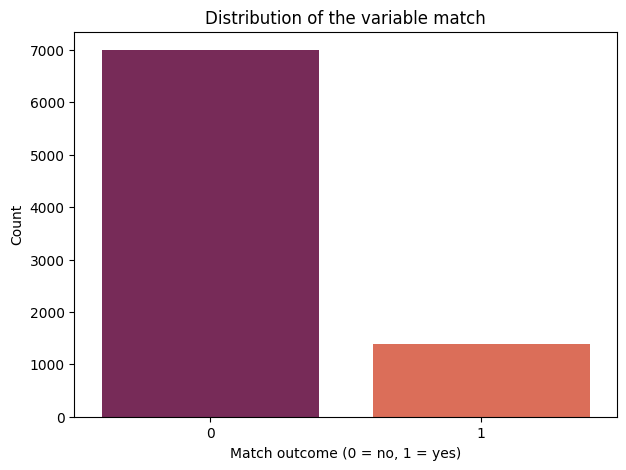

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(x="match", data=df,  palette="rocket")

plt.title("Distribution of the variable match")
plt.xlabel("Match outcome (0 = no, 1 = yes)")
plt.ylabel("Count")

Note: this 16.5% is the per-date mutual match rate. Individual yes-rates are higher (~43%), but both parties must agree for a match.

### Comparing rating of the participant rating themself and their partner rating the participant

histograms for other variables

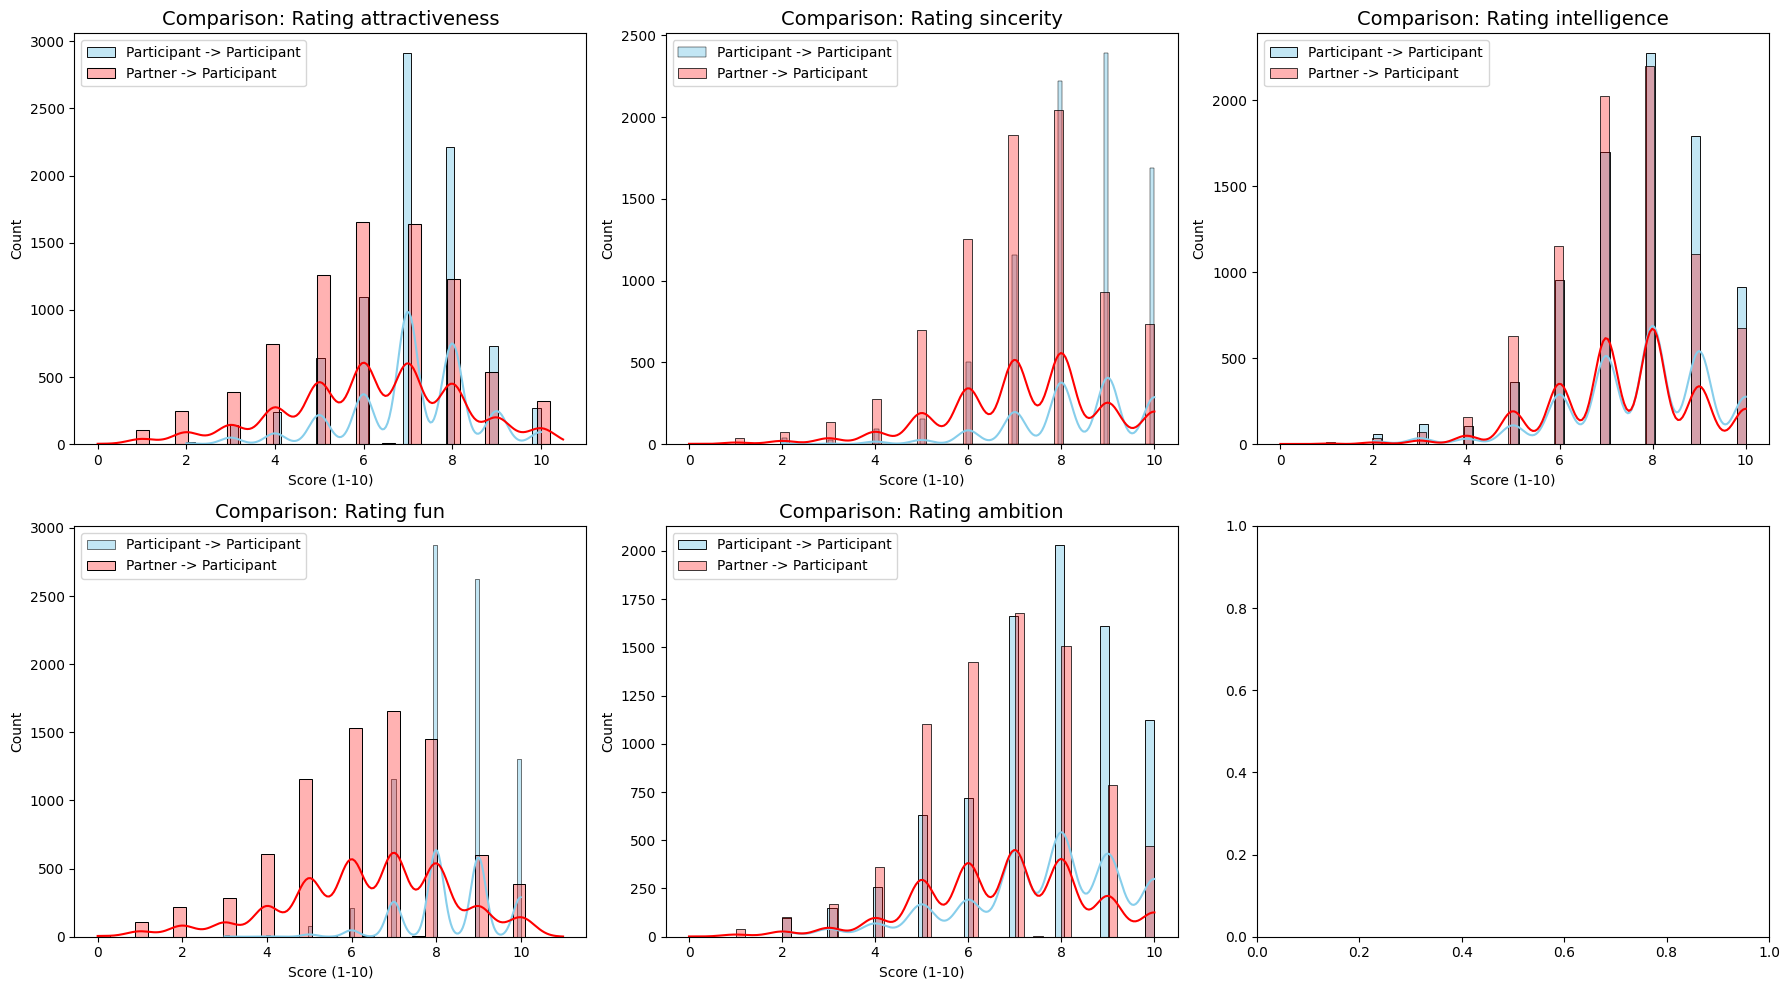

In [ ]:
# pairing the values of a participant rating themself and their partner rating the participant.
pairs = [
    ("attractive", "attractive_o", "Rating attractiveness"),
    ("sincere", "sinsere_o", "Rating sincerity"),
    ("intelligence", "intelligence_o", "Rating intelligence"),
    ("funny", "funny_o", "Rating fun"),
    ("ambition", "ambitous_o", "Rating ambition"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (self_rate, partner_rate, title) in enumerate(pairs):

    sns.histplot(df[self_rate].dropna(), color="skyblue", label="Participant -> Participant",
                 kde=True, ax=axes[i], alpha=0.5)
    sns.histplot(df[partner_rate].dropna(), color="red", label="Partner -> Participant",
                 kde=True, ax=axes[i], alpha=0.3)

    axes[i].set_title(f"Comparison: {title}", fontsize=14)
    axes[i].set_xlabel("Score (1-10)")
    axes[i].legend()

plt.tight_layout()
plt.show()

### Relation between selected predictors and the target variable

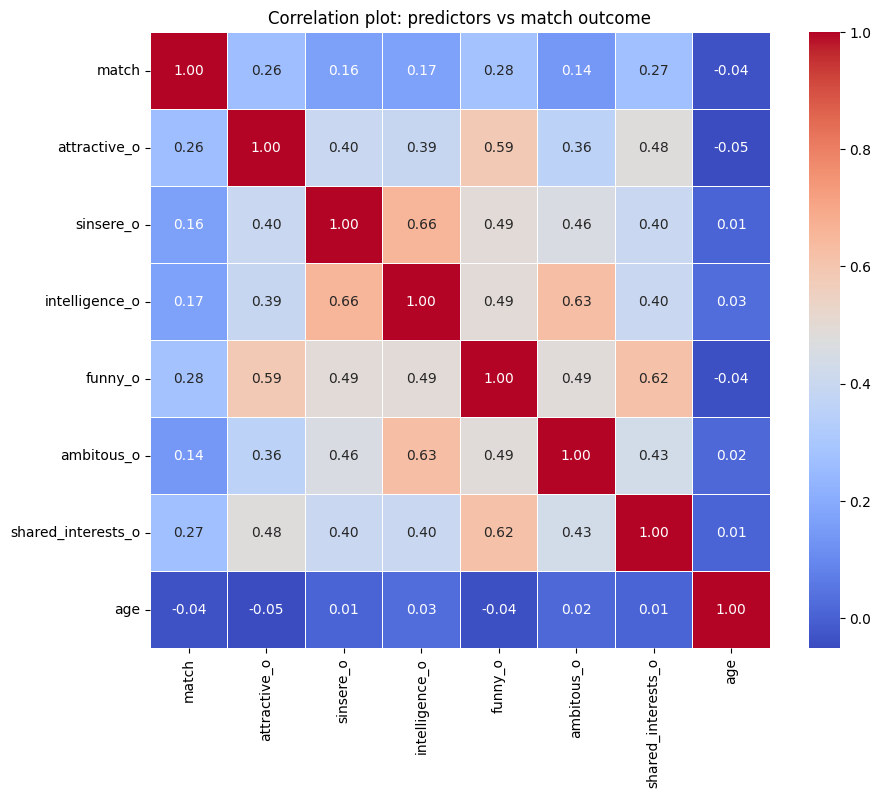

In [ ]:

predictors = ['match', 'attractive_o', 'sinsere_o', 'intelligence_o',
              'funny_o', 'ambitous_o', 'shared_interests_o', 'age']

corr = df[predictors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation plot: predictors vs match outcome")
plt.show()

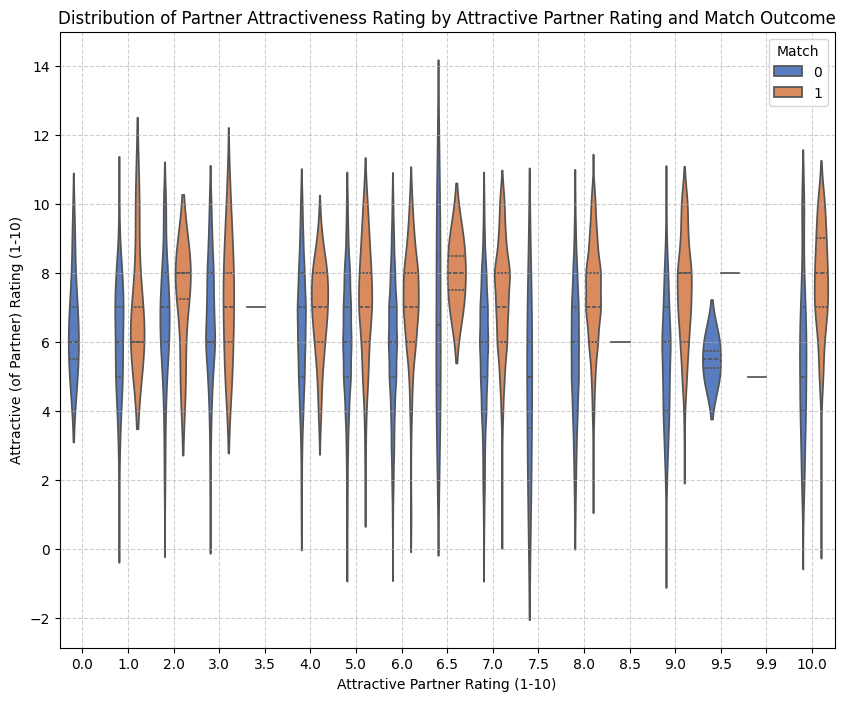

In [ ]:
df_plot = df.copy()
df_plot['match'] = df_plot['match'].astype(int)

plt.figure(figsize=(10, 8))
sns.violinplot(x='attractive_partner', y='attractive_o', hue='match', data=df_plot, inner='quartile', dodge=True, palette='muted')
plt.title('Distribution of Partner Attractiveness Rating by Attractive Partner Rating and Match Outcome')
plt.xlabel('Attractive Partner Rating (1-10)')
plt.ylabel('Attractive (of Partner) Rating (1-10)')
plt.legend(title='Match')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Attractive Partner Rating means how was subject rated by his/her partner.

Attractive (of Partner) Rating means how our subject rated attravity of his/her partner.

### Exploring missing values

/tmp/ipykernel_2463/2202942847.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data.values,  palette="rocket")


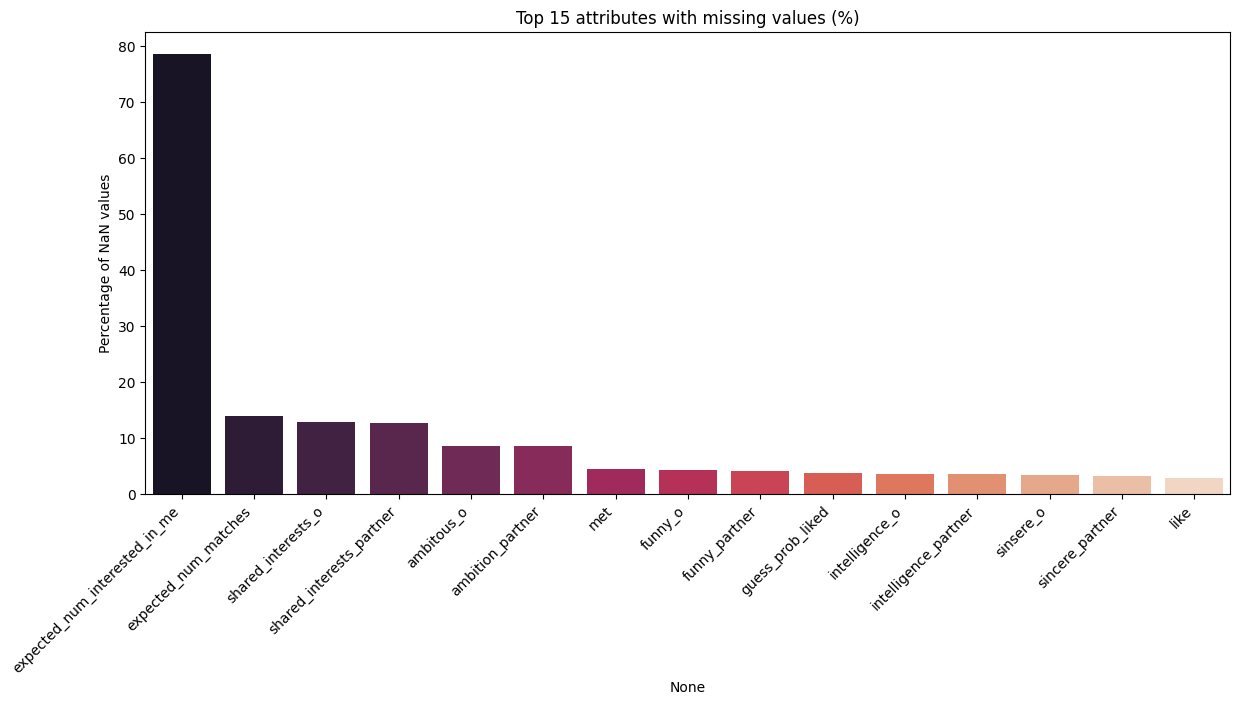

In [ ]:
missing_data = df.isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x=missing_data.index, y=missing_data.values,  palette="rocket")

plt.title("Top 15 attributes with missing values (%)")
plt.ylabel("Percentage of NaN values")
plt.xticks(rotation=45, ha="right")
plt.show()

### Does age difference matter?

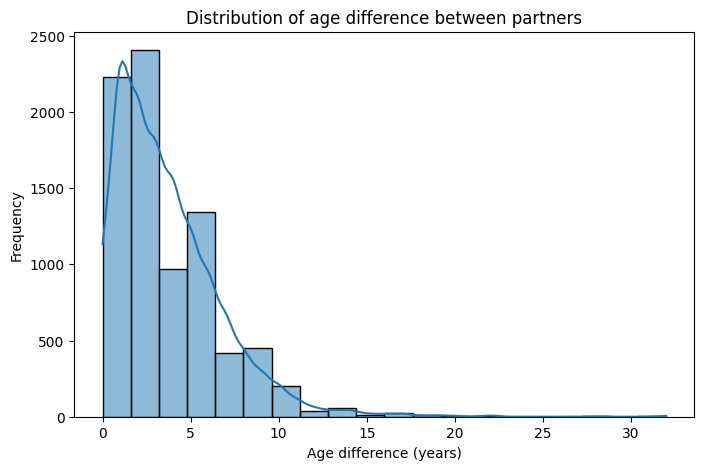

In [ ]:
df["age_diff"] = abs(df["age"] - df["age_o"])

plt.figure(figsize=(8, 5))
sns.histplot(df["age_diff"].dropna(), bins=20, kde=True)

plt.title("Distribution of age difference between partners")
plt.xlabel("Age difference (years)")
plt.ylabel("Frequency")
plt.show()

### Importance of different characteristics

/tmp/ipykernel_2463/1029329095.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_labels, y=averages.values, palette="Blues_r")


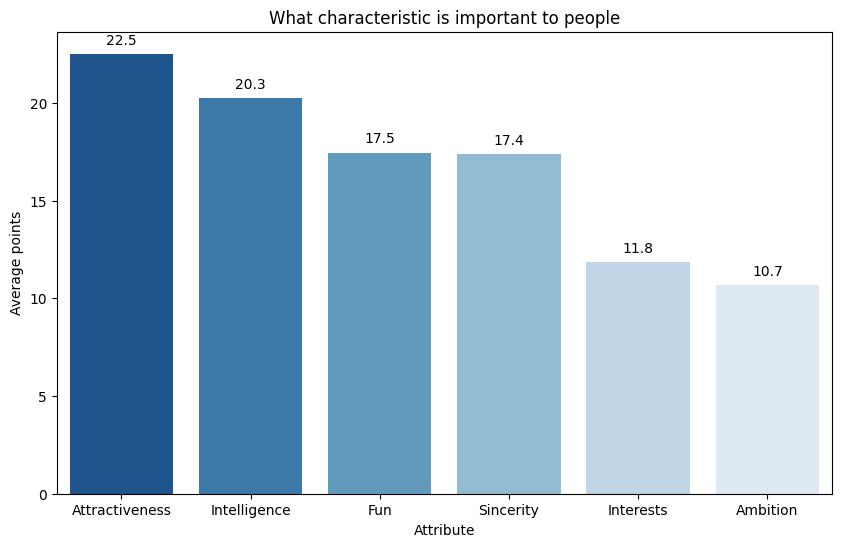

In [ ]:
pref_cols = [
    "attractive_important", "sincere_important", "intellicence_important",
    "funny_important", "ambtition_important", "shared_interests_important"
]
labels = ["Attractiveness", "Sincerity", "Intelligence", "Fun", "Ambition", "Interests"]
#average value
averages = df[pref_cols].mean().sort_values(ascending=False)

sorted_labels = [labels[pref_cols.index(col)] for col in averages.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_labels, y=averages.values, palette="Blues_r")

plt.title("What characteristic is important to people")
plt.ylabel("Average points")
plt.xlabel("Attribute")

#for more precise results
for i, val in enumerate(averages.values):
    plt.text(i, val + 0.5, f"{val:.1f}", ha="center")

plt.show()

### Most common interests

/tmp/ipykernel_2463/1666312244.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=interest_means.index, y=interest_means.values, palette="rocket")


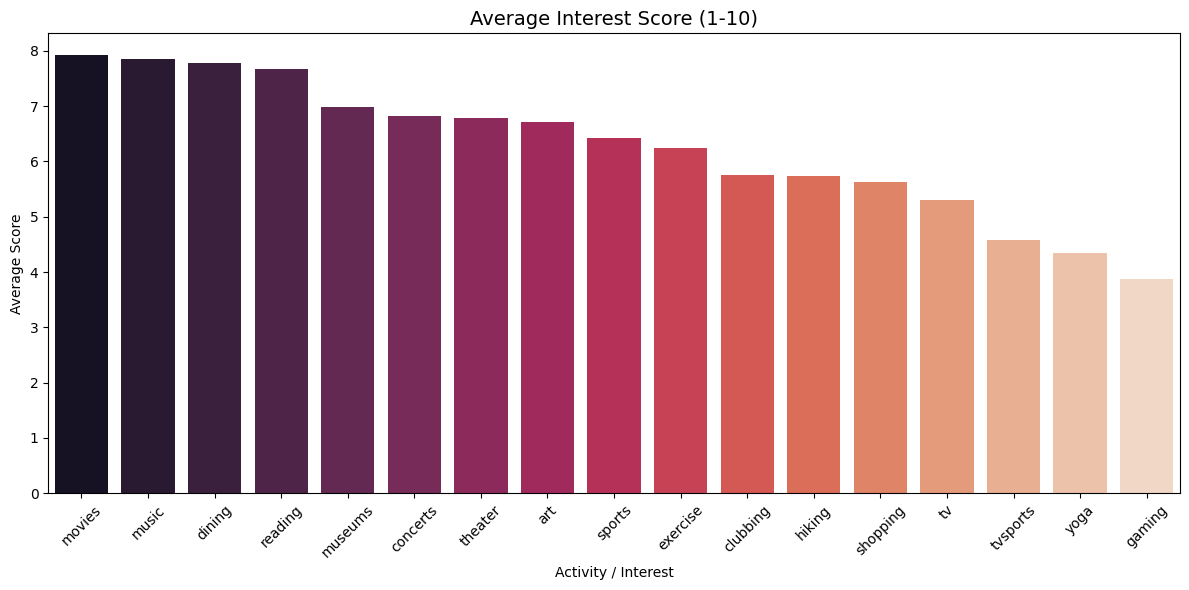

In [ ]:
interest_cols = [
    "sports", "tvsports", "exercise", "dining", "museums",
    "art", "hiking", "gaming", "clubbing", "reading",
    "tv", "theater", "movies", "concerts", "music",
    "shopping", "yoga"
]
# sorted means
interest_means = df[interest_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=interest_means.index, y=interest_means.values, palette="rocket")

plt.title("Average Interest Score (1-10)", fontsize=14)
plt.ylabel("Average Score")
plt.xlabel("Activity / Interest")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation



The data shows that a real "match" is actually quite rare. Only about 16% of dates ended with both people agreeing to meet again. This means that mutual attraction is hard to find in just four minutes. So the model will have to predict based on matches, even though most dates did not end in a match.

There is also a big difference between what people say they want and who they actually pick. Before the dating started, many people said they wanted someone "intelligent" or "sincere." However, the results show that these traits did not predict a match very well. Instead, attractiveness and being fun were the most important factors. If a person found their partner good-looking and funny, they usually said "yes," even if that partner didn't fit their original plan.

The correlation matrix shows that the strongest positive correlations with match are from during-date ratings of attractiveness, fun, and shared interests (correlations around 0.3–0.4). Demographic variables like age show near-zero correlation. We therefore expect the model to lean on during-date ratings more than on pre-event preferences.

Finally, simple facts like age, race or field of study were not very strong predictors of a match. This is why our model should focus on the ratings people gave each other during the date. Because matches are so rare and valuable, our cost matrix is designed to make sure the model doesn't miss a real connection, even if it has to suggest a few mismatches along the way.

###

# Data preprocessing

## Preprocessing for supervised machine learning

### Derive binary target attribute (if not already binary)

The attribute 'match' is already a binary variable. Therefore, we do not have to derive it.

### Train test split

We checked missing values in all variables. Median inputation method was chosen to impute those missing values.

In [ ]:
#We chose 80% of the data for training, and the remaining 20% for testing
baseline = [
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
    'attractive_partner', 'sincere_partner', 'intelligence_partner',
    'funny_partner', 'ambition_partner', 'shared_interests_partner']
# F1: 0.53 in testing

prefs = ['attractive_important', 'sincere_important', 'intellicence_important',
        'funny_important', 'ambtition_important', 'shared_interests_important',
        'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence',
        'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests']
# F1: 0.56 in testing

predictors = baseline + prefs + ['interests_correlate']
# F1: 0.57 in testing

columns = ['match'] + predictors

df_final = df[columns]

X = df_final.drop('match', axis=1)
y = df_final['match'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We performed an 80/20 split of our dataset. We decided to use only the selected predictors for the train-test split to avoid overfitting and to achieve a more accurate predicting model. By selecting specific predictors, we reduced the dimensionality of the dataset. This helps the model focus on variables with the highest explanatory power, such as personality traits and physical attractiveness.

### Feature engineering

In [ ]:
# How much values are missing
missing_info = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Ratio (%)': (df.isnull().sum() / len(df)) * 100
})

# Filter to show only columns with missing values and sort by ratio
missing_info = missing_info[missing_info['Missing Values'] > 0].sort_values(by='Missing Ratio (%)', ascending=False)

print("Missing Values and Their Ratios in the Dataset")
display(missing_info)

Missing Values and Their Ratios in the Dataset


,Missing Values,Missing Ratio (%)
expected_num_interested_in_me,6578,78.515159
expected_num_matches,1173,14.000955
shared_interests_o,1076,12.843161
shared_interests_partner,1067,12.735736
ambitous_o,722,8.617809
...,...,...
concerts,79,0.942946
reading,79,0.942946
race_o,73,0.871330
race,63,0.751969


In [ ]:
num_cols = X_train.select_dtypes(include=['number']).columns

#fill missing value with mean
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train[num_cols])

#final
X_train[num_cols] = imputer.transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

For the feature engineering phase, we opted for filling missing values with the mean, as it preserves the integrity of our dataset by keeping as many observations as possible.The imputer was fitted only on the training data to prevent data leakage.

## Applying preprocessing on test data

## Modeling

### Classifier 1 (basic decision tree)

Due to the imbalance of the dataset basic decision tree is not very suitable, first version of decision tree with parameters set exactly to max depth of 5 was capable reach accuracy little bit over 0.83, which was basically like predicting the most common value. Because of this, gridsearch algorithm was used to model a tree.

 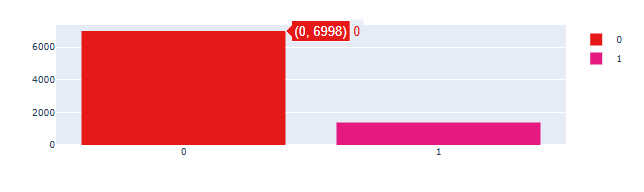

Parameters to try when bulding a tree are set inside dictionary *param_grid*.

In [ ]:
print(X_test.head())

      attractive_o  sinsere_o  intelligence_o  funny_o  ambitous_o  shared_interests_o  attractive_partner  sincere_partner  intelligence_partner  funny_partner  ambition_partner  shared_interests_partner  attractive_important  sincere_important  intellicence_important  funny_important  ambtition_important  shared_interests_important  pref_o_attractive  pref_o_sincere  pref_o_intelligence  pref_o_funny  pref_o_ambitious  pref_o_shared_interests  interests_correlate
4730           7.0        8.0             8.0      6.0         6.0                 6.0                 4.0              8.0                   6.0            6.0               6.0                       4.0                 19.00              13.00                   18.00            18.00                10.00                       22.00               16.0            20.0                 19.0          16.0              18.0                     11.0                -0.18
8168           6.0        7.0             7.0      7.0      

In [ ]:
params_grid = {
    'max_depth':        [3, 5, 7, 10, 15, None],   # None = unlimited depth
    'min_samples_split': [2, 10, 20, 50],           # min samples needed to split a node
    'min_samples_leaf':  [1, 5, 10, 20],            # min samples required at a leaf
    'criterion':        ['entropy']          # split quality measure
}

In [ ]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_tree = DecisionTreeClassifier(
    class_weight='balanced',  # Handle class imbalance
    random_state=42
)

# Use F1
grid_search = GridSearchCV(
    base_tree,
    params_grid,
    cv=stratified_cv,
    scoring='f1',  # Changed from accuracy
    n_jobs=-1,
    verbose=1
)

treemodel = grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


In [ ]:
# decision trees built
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation F1 score:", round(grid_search.best_score_, 4))

# Show top 10 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')
print("\nTop 10 parameter combinations:")
print(results_df[['param_max_depth', 'param_criterion',
                   'param_min_samples_split', 'param_min_samples_leaf',
                   'mean_test_score', 'std_test_score']].head(10).to_string(index=False))


# fit the model (done automatically)
best_tree = grid_search.best_estimator_


Best parameters found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best cross-validation F1 score: 0.4704

Top 10 parameter combinations:
param_max_depth param_criterion  param_min_samples_split  param_min_samples_leaf  mean_test_score  std_test_score
              5         entropy                       50                      20         0.470376        0.015955
              5         entropy                       20                      20         0.470376        0.015955
              5         entropy                       10                      20         0.470376        0.015955
              5         entropy                        2                      20         0.470376        0.015955
              5         entropy                       50                       1         0.467823        0.015034
              5         entropy                       20                       1         0.467823        0.015034
              5    

In [ ]:
sample = X_test.iloc[[10]]
sample

,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,attractive_important,sincere_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,interests_correlate
5214,6.0,7.0,7.0,7.0,7.0,6.0,3.0,3.0,3.0,2.0,3.0,0.0,15.0,15.0,30.0,15.0,15.0,10.0,40.0,0.0,10.0,50.0,0.0,0.0,0.05


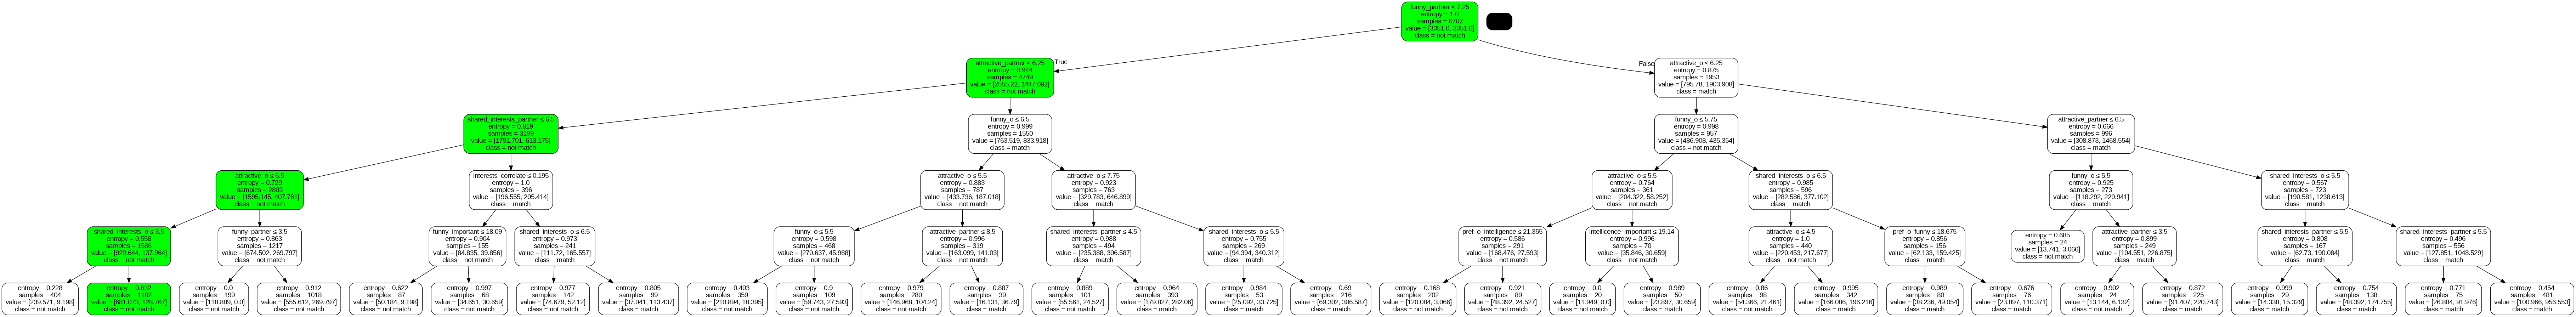

In [ ]:
# show the decision path
featurenames= best_tree.feature_names_in_
featurenames
classnames =["not match","match"]

import pydotplus
from sklearn import tree
clf=best_tree
dot_data = tree.export_graphviz(clf, out_file=None,
                                feature_names=list(featurenames),
                                class_names=classnames,
                                filled=True, rounded=True,
                                special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data)

# empty all nodes, i.e.set color to white and number of samples to zero
for node in graph.get_node_list():
    if node.get_attributes().get('label') is None:
        continue
    if 'samples = ' in node.get_attributes()['label']:
        labels = node.get_attributes()['label'].split('<br/>')
        for i, label in enumerate(labels):
            if label.startswith('samples = '):
                pass
                #labels[i] = 'samples = 0'
        node.set('label', '<br/>'.join(labels))
        node.set_fillcolor('white')

samples = sample
decision_paths = clf.decision_path(samples)

for decision_path in decision_paths:
    for n, node_value in enumerate(decision_path.toarray()[0]):
        if node_value == 0:
            continue
        node = graph.get_node(str(n))[0]
        node.set_fillcolor('green')
        labels = node.get_attributes()['label'].split('<br/>')
        for i, label in enumerate(labels):
            if label.startswith('samples = '):
                pass
                #labels[i] = 'samples = {}'.format(int(label.split('=')[1]) + 1)

        node.set('label', '<br/>'.join(labels))

#filename = 'tree.png'
#graph.write_png(filename)
from IPython.display import Image
Image(graph.create_png())

### Classifier 2 (random forest)

Basic random forest does not handle well the imbalance of the dataset, therefore we decided to use GridSearchCV to optimize the hyperparameters for the Random Forest classficator.

First we define grid of parameters to be used while searching for the best forest. Then we perform set up of the forest classifier and fitting. Evalutation of the classifier is performed in the next step.

In [ ]:
params_grid_rf = {
    'n_estimators': [100, 200, 300], # number of trees in the forest
    'max_depth': [None,3, 5, 10], # max depth of the tree
    'min_samples_split': [2, 4, 5, 10], # min number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # min number of samples required to be at a leaf node
    'criterion': ['entropy'] # function to measure the quality of a split
}

In [ ]:
base_rf = RandomForestClassifier(
    class_weight='balanced', # class imbalance handling
    random_state=42
)

stratified_cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_rf = GridSearchCV(
    base_rf,
    params_grid_rf,
    cv=stratified_cv_rf,
    scoring='f1', # F1 is used to cope with class imbalance
    n_jobs=-1, # Use all available cores
    verbose=1
)

In [ ]:
clf_rf = grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


Prediction

In [ ]:
y_pred_rf = clf_rf.predict(X_test)
y_pred_rf

array([0, 0, 1, ..., 0, 0, 0])

### Classifier 3 (baseline)

Most frequent class predictor. Always predicts *no-match*.

In [ ]:
def mostFrequentClassPredictor(y_train):
    # Determine the most frequent class in the training data
    # y_train is a Series, its mode() will return the most frequent value.
    # If there's a tie, it returns all modes, but for a single class, it will be one value.
    most_frequent_class = y_train.mode()[0]
    return most_frequent_class

In [ ]:
# Determine the most frequent class from the training data
most_frequent_class = mostFrequentClassPredictor(y_train)

# Create baseline predictions: all test instances are predicted as the most frequent class
predictions_baseline = [most_frequent_class for _ in range(len(X_test))]

# Evaluation

### Classifier 1 (decision tree)

In [ ]:
from sklearn.metrics import f1_score

# Predictions
predictions_best = best_tree.predict(X_test)

# Convert predictions_best to numeric for metric calculation
predictions_best_numeric = predictions_best.astype(int)

best_acc = accuracy_score(y_test, predictions_best_numeric)
best_f1 = f1_score(y_test, predictions_best_numeric)


print(f"Best model accuracy:                  {best_acc:.4f}")
print(f"Best model F1 score:                  {best_f1:.4f}")

# Detailed breakdown, important given class imbalance!
print("\nClassification Report:")
print(classification_report(y_test, predictions_best_numeric, target_names=["no match", "match"]))

Best model accuracy:                  0.7124
Best model F1 score:                  0.4633

Classification Report:
              precision    recall  f1-score   support

    no match       0.93      0.71      0.80      1389
       match       0.34      0.72      0.46       287

    accuracy                           0.71      1676
   macro avg       0.63      0.72      0.63      1676
weighted avg       0.83      0.71      0.75      1676



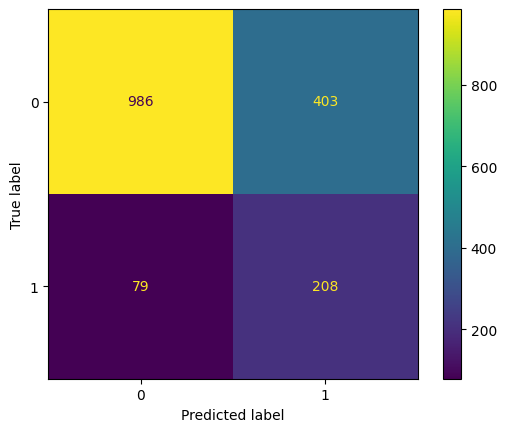

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm=confusion_matrix(y_test, y_pred= predictions_best )

# Display the matrix
cm_display = ConfusionMatrixDisplay(cm).plot()

Original cost matrix specified in the introduction:
| | Predicted: 0 (No Match) | Predicted: 1 (Match) |
|---|:---:|:---:|
| **Actual: 0 (No Match)** | 0 (TN) | 1 (FP) |
| **Actual: 1 (Match)** | 2 (FN) | 0 (TP) |

In [ ]:
# Multiplied by predefined values
TN = cm[0, 0] # True Negative (correctly predicted "no match")
FP = cm[0, 1] # False Positive (predicted "match" but was "no match")
FN = cm[1, 0] # False Negative (predicted "no match" but was "match")
TP = cm[1, 1] # True Positive (correctly predicted "match")
total_cost = TN*0 + FP*1 + FN*2 + TP*0

print(f"TN: {TN}, FP: {FP}")
print(f"FN: {FN}, TP: {TP}")

print(f"Total cost: {total_cost}")
print(f"Average cost per sample: {total_cost / len(y_test)}")

TN: 986, FP: 403
FN: 79, TP: 208
Total cost: 561
Average cost per sample: 0.3347255369928401


### Classifier 2 (random forest)

In [ ]:
# Accuracy score and F1 score
print(f"accuracy score RandomForest: {accuracy_score(y_test, y_pred_rf)}")
# Convert y_pred_rf to numeric for f1_score
y_pred_rf_numeric = y_pred_rf.astype(int)
print(f"F1 score RandomForest: {f1_score(y_test, y_pred_rf_numeric)}")

# Detailed breakdown, important given class imbalance!
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_numeric, target_names=["no match", "match"]))

accuracy score RandomForest: 0.8186157517899761
F1 score RandomForest: 0.5128205128205128

Classification Report:
              precision    recall  f1-score   support

    no match       0.91      0.87      0.89      1389
       match       0.47      0.56      0.51       287

    accuracy                           0.82      1676
   macro avg       0.69      0.72      0.70      1676
weighted avg       0.83      0.82      0.82      1676



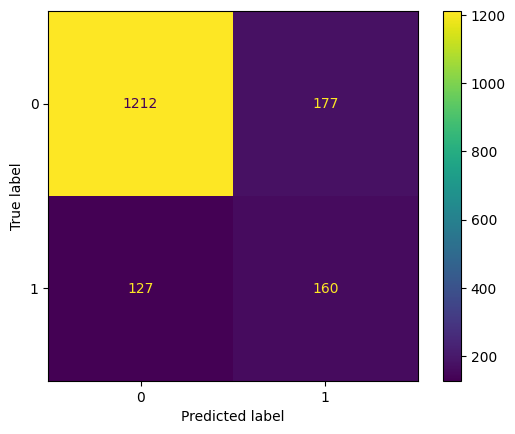

In [ ]:
cm=confusion_matrix(y_test, y_pred= y_pred_rf )

# Display the matrix
cm_display = ConfusionMatrixDisplay(cm).plot()

Cost matrix * confusion matrix calculations

In [ ]:
# Multiplied by predefined values
TN = cm[0, 0] # True Negative (correctly predicted "no match")
FP = cm[0, 1] # False Positive (predicted "match" but was "no match")
FN = cm[1, 0] # False Negative (predicted "no match" but was "match")
TP = cm[1, 1] # True Positive (correctly predicted "match")
total_cost = TN*0 + FP*1 + FN*2 + TP*0

print(f"TN: {TN}, FP: {FP}")
print(f"FN: {FN}, TP: {TP}")

print(f"Total cost: {total_cost}")
print(f"Average cost per sample: {total_cost / len(y_test)}")

TN: 1212, FP: 177
FN: 127, TP: 160
Total cost: 431
Average cost per sample: 0.2571599045346062


### Classifier 3 (baseline)

In [ ]:
# Convert predictions_baseline to numeric for metric calculation
predictions_baseline_numeric = pd.Series(predictions_baseline).astype(int)

# Calculate metrics for the baseline model
baseline_acc = accuracy_score(y_test, predictions_baseline_numeric)
baseline_f1 = f1_score(y_test, predictions_baseline_numeric)

print(f"Baseline model accuracy:                  {baseline_acc:.4f}")
print(f"Baseline model F1 score:                  {baseline_f1:.4f}")

# Detailed breakdown, important given class imbalance!
print("\nClassification Report (Baseline):")
print(classification_report(y_test, predictions_baseline_numeric, target_names=["no match", "match"]))



Baseline model accuracy:                  0.8288
Baseline model F1 score:                  0.0000

Classification Report (Baseline):
              precision    recall  f1-score   support

    no match       0.83      1.00      0.91      1389
       match       0.00      0.00      0.00       287

    accuracy                           0.83      1676
   macro avg       0.41      0.50      0.45      1676
weighted avg       0.69      0.83      0.75      1676



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


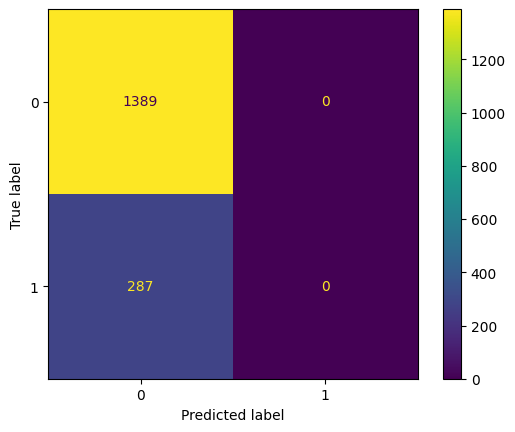

In [ ]:
# Display the matrix
cm_baseline=confusion_matrix(y_test, y_pred= predictions_baseline )
cm_display = ConfusionMatrixDisplay(cm_baseline).plot()

In [ ]:
# Calculate cost for baseline model
TN_baseline = cm_baseline[0, 0]
FP_baseline = cm_baseline[0, 1]
FN_baseline = cm_baseline[1, 0]
TP_baseline = cm_baseline[1, 1]
total_cost_baseline = TN_baseline*0 + FP_baseline*1 + FN_baseline*2 + TP_baseline*0

print(f"\nBaseline TN: {TN_baseline}, FP: {FP_baseline}")
print(f"Baseline FN: {FN_baseline}, TP: {TP_baseline}")
print(f"Total cost (Baseline): {total_cost_baseline}")
print(f"Average cost per sample (Baseline): {total_cost_baseline / len(y_test)}")


Baseline TN: 1389, FP: 0
Baseline FN: 287, TP: 0
Total cost (Baseline): 574
Average cost per sample (Baseline): 0.3424821002386635


### Summary

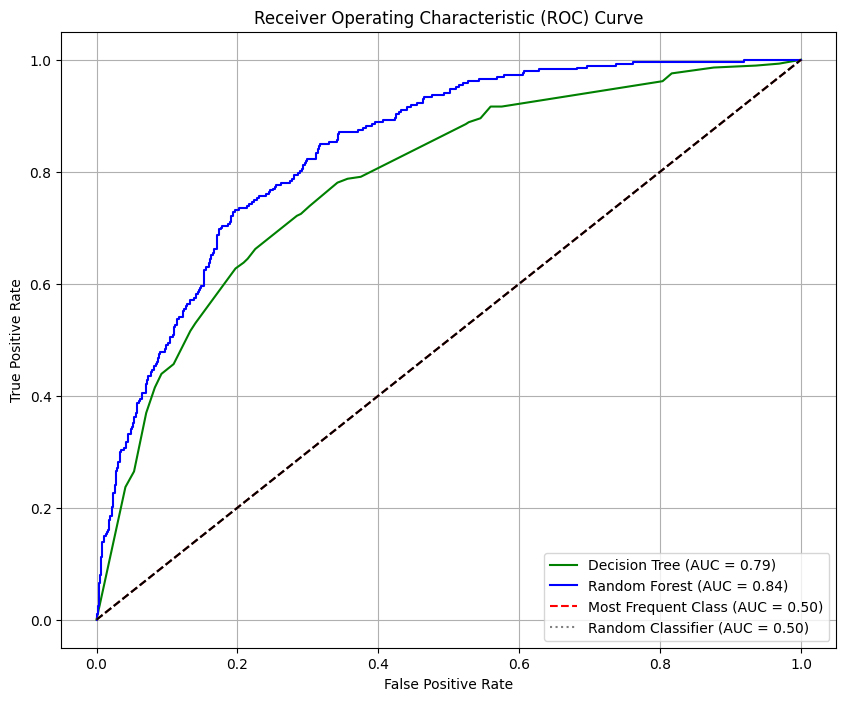

In [ ]:
# ROC curve evaluation summary - decision tree, random forest, baseline
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt

# Ensure y_test is numeric
y_test_numeric = y_test.astype(int)

# 1. Decision Tree (best_tree)
y_prob_dt = best_tree.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test_numeric, y_prob_dt)
auc_dt = roc_auc_score(y_test_numeric, y_prob_dt)

# 2. Random Forest (clf_rf)
y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_numeric, y_prob_rf)
auc_rf = roc_auc_score(y_test_numeric, y_prob_rf)

# 3. Baseline Classifier (Most Frequent Class - DummyClassifier with 'prior' strategy)
dummy_mfc = DummyClassifier(strategy='prior', random_state=42)
dummy_mfc.fit(X_train, y_train.astype(int)) # Fit on numeric y_train
y_prob_mfc = dummy_mfc.predict_proba(X_test)[:, 1]
fpr_mfc, tpr_mfc, thresholds_mfc = roc_curve(y_test_numeric, y_prob_mfc)
auc_mfc = roc_auc_score(y_test_numeric, y_prob_mfc)

# 4. Random Classifier (No-skill line - DummyClassifier with 'uniform' strategy)
dummy_random = DummyClassifier(strategy='uniform', random_state=42)
dummy_random.fit(X_train, y_train.astype(int))
y_prob_random = dummy_random.predict_proba(X_test)[:, 1]
fpr_random, tpr_random, thresholds_random = roc_curve(y_test_numeric, y_prob_random)
auc_random = roc_auc_score(y_test_numeric, y_prob_random)

# Plotting the ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})', color='green')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='blue')
plt.plot(fpr_mfc, tpr_mfc, label=f'Most Frequent Class (AUC = {auc_mfc:.2f})', color='red', linestyle='--')
plt.plot(fpr_random, tpr_random, label=f'Random Classifier (AUC = {auc_random:.2f})', color='grey', linestyle=':')

plt.plot([0, 1], [0, 1], 'k--') # Diagonal random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Performance Comparison Table**

| Metric | Decision Tree | Random Forest | Baseline | Winner |
|--------|:---:|:---:|:---:|:---:|
| **F1 Score** | 0.4600 | **0.5128** | 0.0000 | Random Forest |
| **Recall** | **0.7200** | 0.5600 | 0.0000 | Decision Tree |
| **Total Cost** | 561 | **431** | 574 | Random Forest |

---

#### Detailed Analysis Summary

*   **Classifier 1: Decision Tree (Optimized via GridSearch)**
    *   The Decision Tree reached an accuracy of 0.7124 on the test set.
    *   It achieved an F1 score of 0.4600.
    *   The recall for the 'match' class is 0.72, meaning it successfully identified 72 % of all actual mutual connections.
    *   This high recall is vital because missing a potential match (False Negative) is the most costly error in our business model.

*   **Classifier 2: Random Forest (Optimized via GridSearch)**
    *   The Random Forest achieved the highest accuracy of 0.8186.
    *   It also produced the best overall F1 score of 0.5128, showing a better balance between precision and recall than the single tree.
    *   However, its recall for matches was lower at 0.56, meaning it missed more genuine connections compared to the Decision Tree at the standard threshold.

*   **Classifier 3: Baseline (Most Frequent Class)**
    *   The baseline model simply predicts 'no match' for every date, resulting in an accuracy of 0.8288 due to the class imbalance.
    *   Because it never predicts a match, its F1 score and recall are both 0.0000, failing to provide any business value.

---

#### Business Impact and Cost Calculation

*   **Decision Tree Business Cost**
    *   Total Cost: 561 units.
    *   Average Cost per Sample: 0.3347.
    *   Reasoning: Its high recall helps avoid the heavy penalty of 2 units for False Negatives (missed connections), though it incurs some costs for False Positives (bad date suggestions).

*   **Random Forest Business Cost**
    *   Total Cost: 431 units.
    *   Average Cost per Sample: 0.2572.
    *   Reasoning: At the default 0.5 threshold, it achieved the lowest total cost by minimizing False Positives significantly while maintaining a decent recall.

*   **Baseline Business Cost**
    *   Total Cost: 574 units.
    *   Average Cost per Sample: 0.3425.
    *   Reasoning: This is the highest cost because the model misses every single actual match in the test set, accumulating a penalty of 2 for each one.

**Final Conclusion**
Our findings suggest that while the Random Forest is more efficient overall at a 0.5 threshold, the Decision Tree is currently our most 'sensitive' model for finding love, as evidenced by its 0.72 recall. In our cost-sensitive environment, avoiding the missed connection is the priority. However it produces a lot of false positive matches.

ROC curve from classes

In [ ]:
def computeInputForROC(y_test,y_pred_prob,thresholds):
    # defining positives and negatives
    positives = np.sum(y_test==1)
    negatives = np.sum(y_test==0)
    debug_df = pd.DataFrame(columns=["threshold","tn", "fp", "fn", "tp","tpr","fpr", "cost"])
    # looping over threshold scores and getting the number of false positives and true positives
    for th in thresholds:
        if th==1.0:
            #for threshold equal to 1.0, all instances need to be classified as negative even if they have probability equal to 1.0
            y_pred_prob_for_th = (y_pred_prob >th).astype(int) #apply threshold for classification
        else:
            y_pred_prob_for_th = (y_pred_prob >=th).astype(int) #apply threshold for classification
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_prob_for_th).ravel()
        tpr=tp/positives
        fpr=fp/negatives
        # Calculate cost based on the cost matrix: FP=1, FN=2
        current_cost = (fp * 1) + (fn * 2)
        new_row = pd.DataFrame({'threshold':th, 'tn':tn, 'fp':fp, 'fn':fn,'tp':tp, 'tpr':tpr, 'fpr':fpr, 'cost': current_cost }, index=[0])
        debug_df = pd.concat([new_row,debug_df.loc[:]]).reset_index(drop=True)
    return(debug_df)

In [ ]:
# compute thresholds and dataframes for ROC curve
thresholds = np.linspace(0,1,99) #let's create 99 nunbers linearly spaced between 0 and 1 (inclusive). The number of values is chosen to ensure that 0.5 appears in the list

debug_df_rf=computeInputForROC(y_test_numeric,y_prob_rf,thresholds)
debug_df_dt=computeInputForROC(y_test_numeric,y_prob_dt,thresholds)
debug_df_mfc=computeInputForROC(y_test_numeric,y_prob_mfc,thresholds)

/tmp/ipykernel_2463/2656980383.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  debug_df = pd.concat([new_row,debug_df.loc[:]]).reset_index(drop=True)
/tmp/ipykernel_2463/2656980383.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  debug_df = pd.concat([new_row,debug_df.loc[:]]).reset_index(drop=True)
/tmp/ipykernel_2463/2656980383.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empt

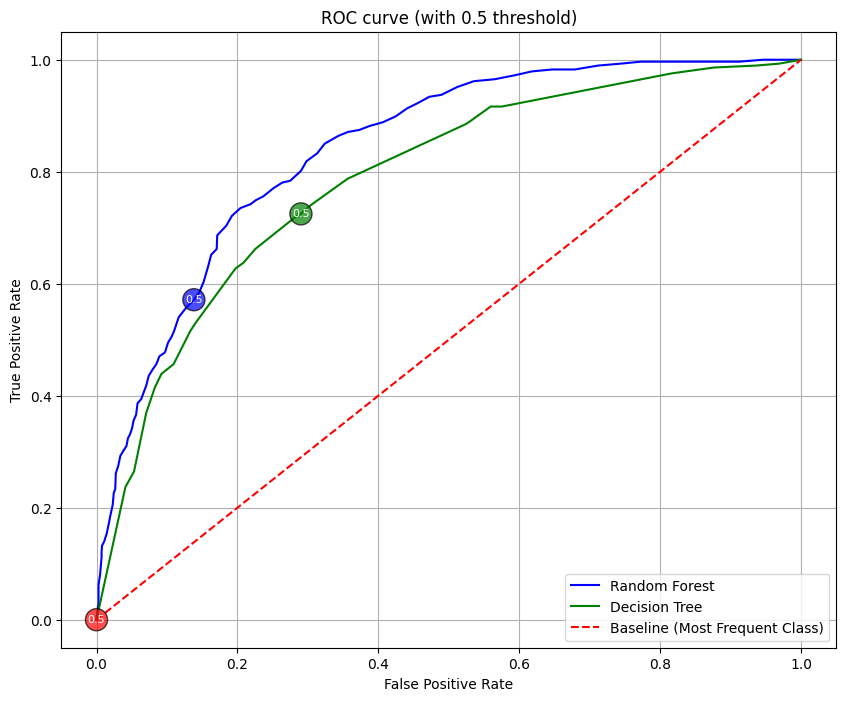

In [ ]:
# chose threshold is 0.5
cm_th05_rf = debug_df_rf.loc[debug_df_rf['threshold'] < 0.49].iloc[0]
cm_th05_dt = debug_df_dt.loc[debug_df_dt['threshold'] < 0.49].iloc[0]
cm_th05_mfc = debug_df_mfc.loc[debug_df_mfc['threshold'] < 0.49].iloc[0]

plt.figure(figsize=(10, 8))
plt.plot(debug_df_rf.fpr, debug_df_rf.tpr, label="Random Forest", color="blue")
plt.plot(debug_df_dt.fpr, debug_df_dt.tpr, label="Decision Tree", color="green")
plt.plot(debug_df_mfc.fpr, debug_df_mfc.tpr, label="Baseline (Most Frequent Class)", color="red", linestyle='--')

# Mark threshold 0.5 for Random Forest
plt.text(cm_th05_rf.fpr, cm_th05_rf.tpr, "0.5", rotation=0, size=8, ha="center", va="center", bbox=dict(boxstyle="Circle", fc="blue", alpha=0.7, pad=0.2), color='white')
# Mark threshold 0.5 for Decision Tree
plt.text(cm_th05_dt.fpr, cm_th05_dt.tpr, "0.5", rotation=0, size=8, ha="center", va="center", bbox=dict(boxstyle="Circle", fc="green", alpha=0.7, pad=0.2), color='white')
# Mark threshold 0.5 for Baseline (Most Frequent Class)
plt.text(cm_th05_mfc.fpr, cm_th05_mfc.tpr, "0.5", rotation=0, size=8, ha="center", va="center", bbox=dict(boxstyle="Circle", fc="red", alpha=0.7, pad=0.2), color='white')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (with 0.5 threshold)")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The ROC curve with the 0.5 threshold marked shows that this threshold is close to optimal for the Decision Tree. For the Random Forest, however, slightly increasing the threshold above 0.5 could improve the true positive rate without substantially raising the false positive rate, which would likely yield better recall.

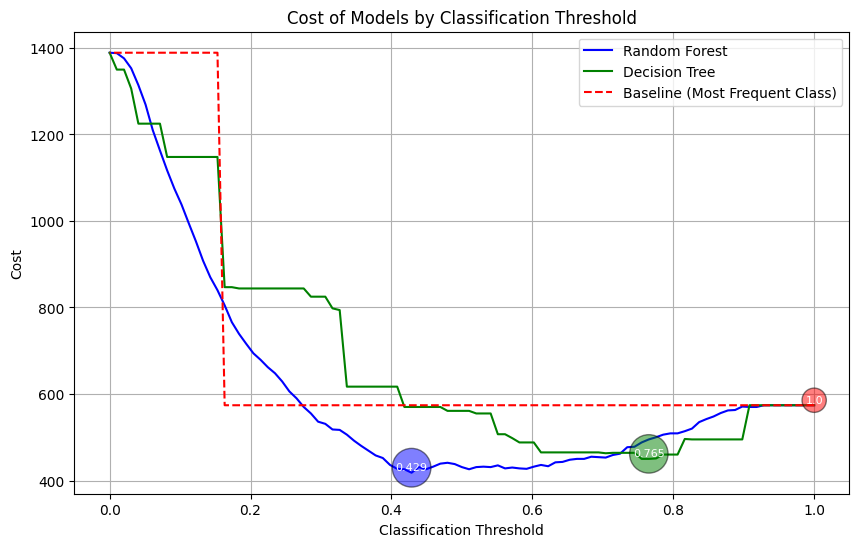

In [ ]:
# Find the threshold that minimizes the total cost for Random Forest
cm_bestCost_rf = debug_df_rf.loc[debug_df_rf['cost'].idxmin()]

# Find the threshold that minimizes the total cost for Decision Tree
cm_bestCost_dt = debug_df_dt.loc[debug_df_dt['cost'].idxmin()]

# Find the threshold that minimizes the total cost for Most Frequent Class (Baseline)
cm_bestCost_mfc = debug_df_mfc.loc[debug_df_mfc['cost'].idxmin()]

plt.figure(figsize=(10, 6))
plt.plot(debug_df_rf.threshold,debug_df_rf.cost, label="Random Forest",color="blue")
plt.text(cm_bestCost_rf.threshold, cm_bestCost_rf.cost, f"{round(cm_bestCost_rf.threshold,3)}", rotation=0, size=8,ha="center", va="bottom",bbox=dict(boxstyle="Circle", fc="blue", alpha=0.5, pad=0.3), color='white')

plt.plot(debug_df_dt.threshold,debug_df_dt.cost, label="Decision Tree",color="green")
plt.text(cm_bestCost_dt.threshold, cm_bestCost_dt.cost, f"{round(cm_bestCost_dt.threshold,3)}", rotation=0, size=8,ha="center", va="bottom",bbox=dict(boxstyle="Circle", fc="green", alpha=0.5, pad=0.3), color='white')

plt.plot(debug_df_mfc.threshold,debug_df_mfc.cost, label="Baseline (Most Frequent Class)",color="red", linestyle='--')
plt.text(cm_bestCost_mfc.threshold, cm_bestCost_mfc.cost, f"{round(cm_bestCost_mfc.threshold,3)}", rotation=0, size=8,ha="center", va="bottom",bbox=dict(boxstyle="Circle", fc="red", alpha=0.5, pad=0.3), color='white')


plt.ylabel('Cost')
plt.xlabel('Classification Threshold')
plt.title("Cost of Models by Classification Threshold")
plt.legend()
plt.grid(True)
plt.show()

Random Forest (blue) reaches its minimum cost of approximately 430 at a threshold of 0.429 — noticeably lower than the default 0.5. The curve is smooth and relatively flat between roughly 0.35 and 0.55, meaning the model is robust to small threshold changes in this region.

Decision Tree (green) reaches its minimum cost of approximately 460 at a threshold of 0.765. The curve is much more jagged and step-shaped, which reflects the fact that a decision tree produces only a small number of discrete probability values — there is no smooth trade-off between thresholds, so the cost can only change when the threshold crosses one of these discrete levels.

Baseline (red dashed) is a step function: up to ~0.16 it predicts everything as "match" (high cost from false positives), and from ~0.16 onward it predicts everything as "no match" (constant cost of ~575 from the missed matches, i.e. false negatives). It has no meaningful threshold to tune.

# Explanation

## Global explanation

This section explains how the supervised models make
predictions. First, we provide a global explanation by identifying the most important variables in the models. Then, we provide a local explanation for one selected observation and analyse how changing the attribute of interest affects the predicted outcome.

### Classifier 1 - decision tree

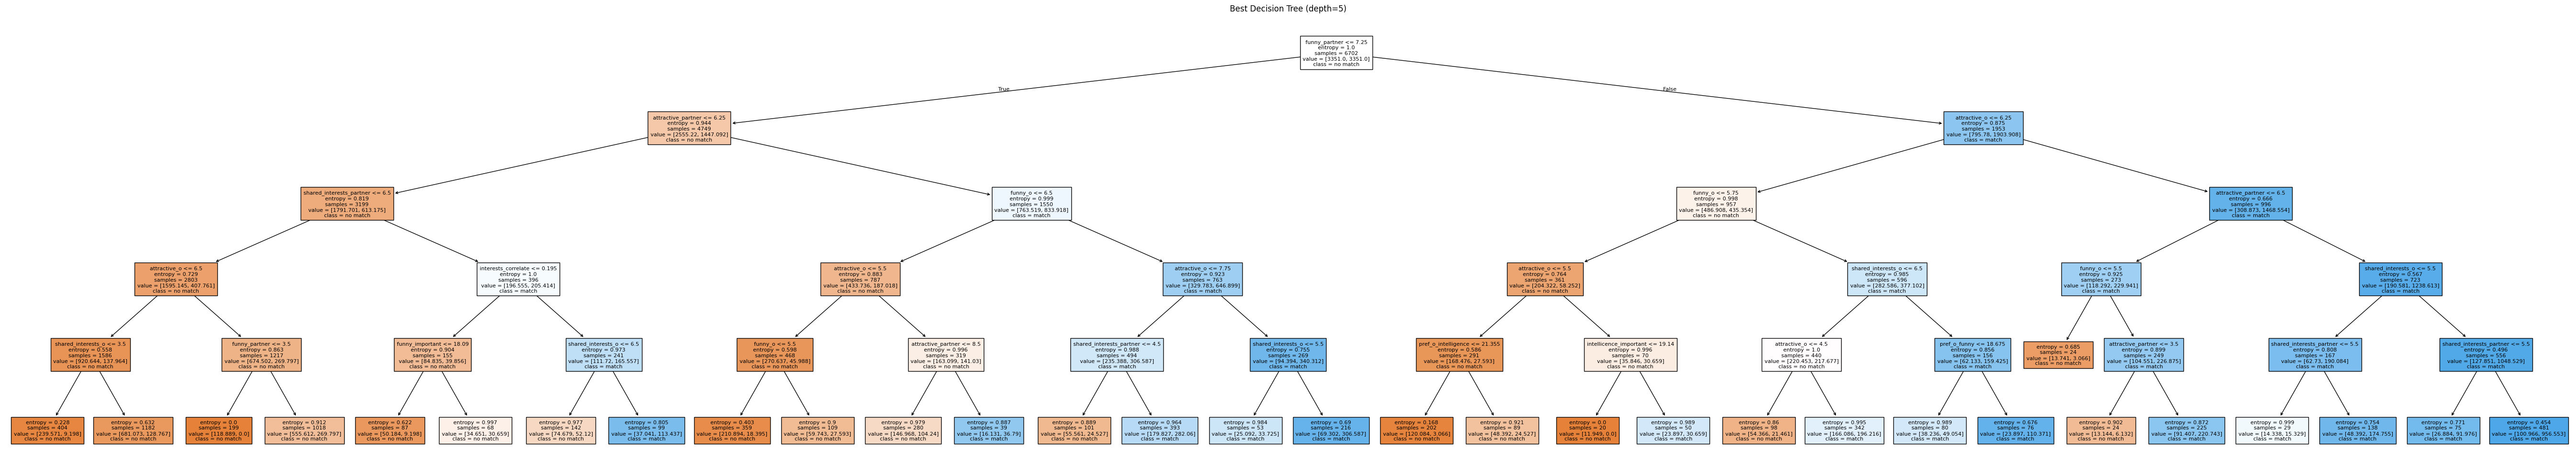

In [ ]:
# Visualise the best tree
plt.figure(figsize=(54, 10))
plot_tree(
    best_tree,
    feature_names=list(X_train.columns),
    class_names=["no match", "match"],
    filled=True,
    fontsize=8,
)
plt.title(f"Best Decision Tree (depth={grid_search.best_params_['max_depth']})")
plt.tight_layout()
plt.show()

funny_partner                 0.325356
attractive_o                  0.227371
attractive_partner            0.147996
funny_o                       0.128412
shared_interests_partner      0.074874
shared_interests_o            0.053285
pref_o_intelligence           0.014083
interests_correlate           0.010113
pref_o_funny                  0.006576
intellicence_important        0.006386
funny_important               0.005548
intelligence_partner          0.000000
ambitous_o                    0.000000
sinsere_o                     0.000000
sincere_partner               0.000000
intelligence_o                0.000000
attractive_important          0.000000
ambtition_important           0.000000
sincere_important             0.000000
ambition_partner              0.000000
shared_interests_important    0.000000
pref_o_sincere                0.000000
pref_o_attractive             0.000000
pref_o_ambitious              0.000000
pref_o_shared_interests       0.000000
dtype: float64


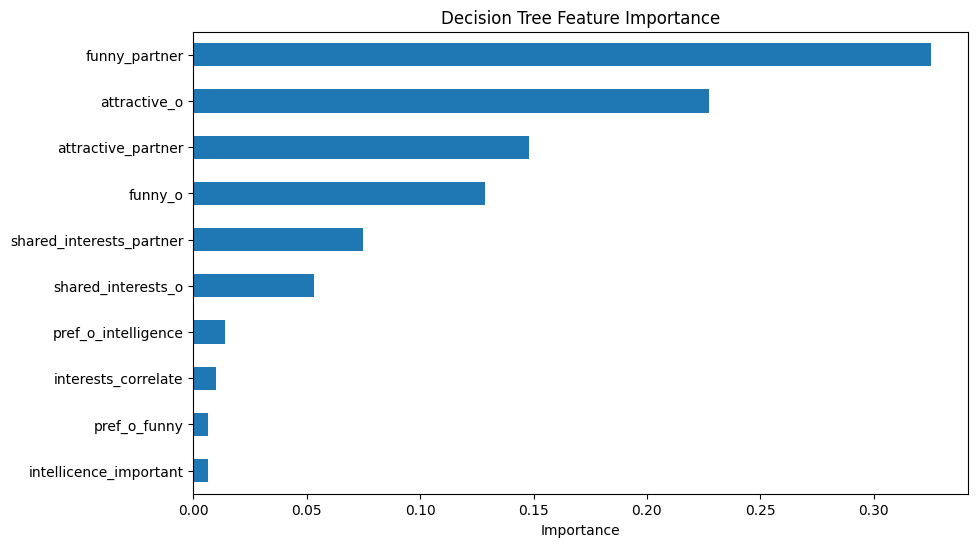

In [ ]:
dt_importance = pd.Series(best_tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(dt_importance)

plt.figure(figsize=(10,6))
dt_importance.head(10).sort_values().plot(kind='barh')
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

The decision tree relies mainly on variables related to fun, attractiveness, and shared interests. The most influential predictor is funny_partner, followed by funny_o, attractive_o, and attractive_partner. This suggests that actual perceived compatibility during the interaction is more important for predicting a match than general preferences or less directly relevant traits. Some variables have zero importance, which means they were not used by the final tree at all.

Zero importance does not necessarily mean that the variable is irrelevant in general. It only means that this specific fitted tree did not use the variable in any decision node.

### Classifier 2 - random forest

attractive_partner            0.110791
attractive_o                  0.104700
funny_partner                 0.091418
funny_o                       0.082623
shared_interests_partner      0.069112
shared_interests_o            0.061506
interests_correlate           0.039558
intellicence_important        0.030112
shared_interests_important    0.027968
pref_o_attractive             0.027737
intelligence_partner          0.027560
pref_o_intelligence           0.027116
attractive_important          0.026638
pref_o_shared_interests       0.025935
ambtition_important           0.024865
intelligence_o                0.024860
pref_o_funny                  0.024569
pref_o_sincere                0.024022
funny_important               0.023565
sincere_important             0.023431
pref_o_ambitious              0.023134
sinsere_o                     0.022517
sincere_partner               0.021914
ambitous_o                    0.017686
ambition_partner              0.016662
dtype: float64


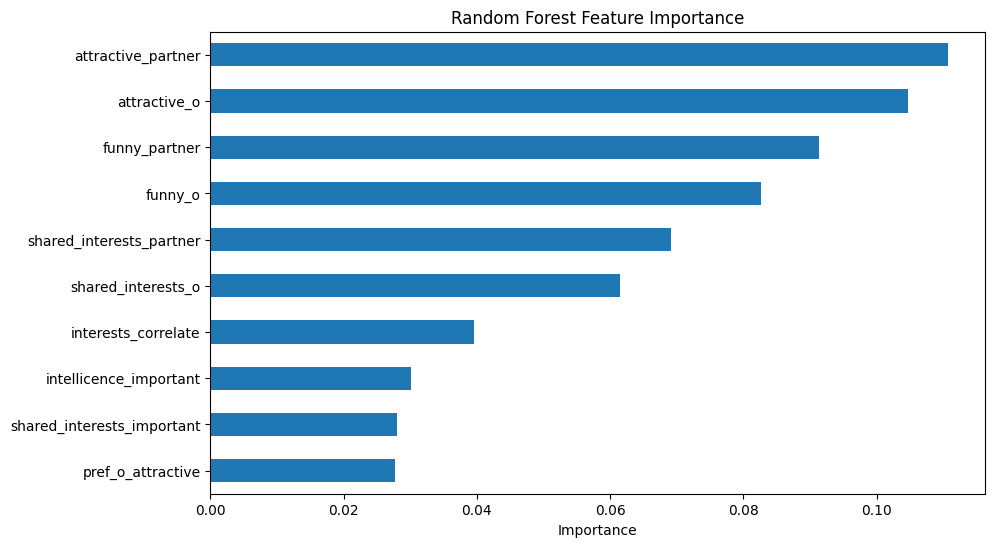

In [ ]:
rf_best = clf_rf.best_estimator_
rf_importance = pd.Series(rf_best.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(rf_importance)

plt.figure(figsize=(10,6))
rf_importance.head(10).sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

The random forest shows that the most important predictors are again variables related to fun, attractiveness, and shared interests. Unlike the decision tree, however, the importance is distributed more evenly across multiple variables. This suggests that the random forest uses a broader combination of compatibility and preference-related features, which makes it less transparent but potentially more robust.

Both models identify fun, attractiveness, and shared interests as the most relevant predictors of a match. However, the decision tree concentrates importance into a smaller number of variables, which makes it easier to interpret. In contrast, the random forest distributes importance across a broader set of predictors, reflecting the fact that it combines many decision trees into one ensemble model. Therefore, the decision tree is more suitable for transparent explanation, while the random forest provides a more aggregated view of predictor influence.

## Local explanation

Selected instance of interest iid = 11.

In [ ]:
  instance_index = 11

# Row from original dataset
# This row contains all original columns, including 'match', and will be used by subsequent cells.
instance_row = df[df['iid'] == instance_index].iloc[0]

# Display the full selected row from the original dataframe
print("Full instance row from the original dataset (df) for iid = 11:")
display(instance_row)

# Prepare the instance_X_df for model prediction and SHAP, using only the selected predictors.
instance_X_df = instance_row[predictors].to_frame().T

Full instance row from the original dataset (df) for iid = 11:


,11
has_null,0
wave,1
gender,female
age,24.0
age_o,22.0
...,...
d_guess_prob_liked,[0-4]
met,0.0
match,0
iid,11


For the local explanation, we selected the instance of interest corresponding to participant iid = 11. The true class of this observation is no match (match = 0). The selected row contains relatively high values for several partner-evaluation variables, such as attractive_o = 7, intelligence_o = 10, and attractive_partner = 8, while interests_correlate = 0.18 indicates relatively low similarity in interests. This instance was used as the input for both supervised models in order to compare their predictions and analyse their behaviour at the individual level.

In [ ]:
import shap

explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(instance_X_df)

shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_values[:, :, 1],  # třídimenzionální output pro jednu instanci
    instance_X_df,
    feature_names=predictors
)

The SHAP force plot shows that the final prediction for the selected instance is f(x) = 0.29, which falls below the decision threshold of 0.5, resulting in a predicted no match. While variables such as funny_o, funny_partner, shared_interests_o and intelligence_partner push the prediction upward toward a match, the attractiveness-related variables — attractive_o and attractive_partner — pull it back down with greater force. The base value of approximately 0.6 represents the average model output across all instances. Overall, the SHAP explanation confirms that despite some positive signals, the attractiveness ratings were not strong enough to overcome the model's baseline tendency and tip the prediction toward a match

Model predictions & agreement for the selected observation






In [ ]:
# match
pred_dt = best_tree.predict(instance_X_df)[0]
pred_rf = clf_rf.predict(instance_X_df)[0]
print(pred_dt)
print(pred_rf)

# confidence
prob_dt = best_tree.predict_proba(instance_X_df)[0]
prob_rf = clf_rf.predict_proba(instance_X_df)[0]
print(max(prob_dt))
print(max(prob_rf))

0
0
0.5850464768138145
0.7617931953068359


The models give the same prediction for the selected instance. The Decision Tree predicts no match, but with only 58.50% confidence, so this is a relatively uncertain prediction. The Random Forest predicts no match with 76.18% confidence, which is noticeably more decisive.

This suggests that while both models arrive at the same conclusion, the Random Forest provides a more reliable prediction for this instance. The Decision Tree's confidence of 58.5% is only slightly above the 0.5 decision threshold, meaning a small change in the input values could flip the prediction. The Random Forest, at 76.18%, is further from the boundary and therefore less sensitive to small perturbations.

Sensitivity analysis of the attribute of interest

In [ ]:
attribute_of_interest = 'attractive_partner'
original_value = instance_X_df[attribute_of_interest].values[0]

print(f"\nSensitivity Analysis: '{attribute_of_interest}'")
print(f"Original value: {original_value}")
print(f"{'Value':>8} | {'DT Prediction':>15} | {'DT P(match)':>12} | "
      f"{'RF Prediction':>15} | {'RF P(match)':>12}")
print("-" * 70)

for val in range(1, 11):  # ratings go 1-10
    modified = instance_X_df.copy()
    modified[attribute_of_interest] = val

    p_dt = best_tree.predict_proba(modified)[0][1]
    p_rf = clf_rf.predict_proba(modified)[0][1]
    pred_dt_v = 'match' if p_dt >= 0.5 else 'no match'
    pred_rf_v = 'match' if p_rf >= 0.5 else 'no match'

    marker = " <-- original" if val == original_value else ""
    print(f"{val:>8} | {pred_dt_v:>15} | {p_dt:>11.2%} | "
          f"{pred_rf_v:>15} | {p_rf:>11.2%}{marker}")


Sensitivity Analysis: 'attractive_partner'
Original value: 8.0
   Value |   DT Prediction |  DT P(match) |   RF Prediction |  RF P(match)
----------------------------------------------------------------------
       1 |        no match |      32.69% |        no match |      18.72%
       2 |        no match |      32.69% |        no match |      18.72%
       3 |        no match |      32.69% |        no match |      18.81%
       4 |        no match |      32.69% |        no match |      21.11%
       5 |        no match |      32.69% |        no match |      23.34%
       6 |        no match |      32.69% |        no match |      23.71%
       7 |        no match |      41.50% |        no match |      23.42%
       8 |        no match |      41.50% |        no match |      23.82% <-- original
       9 |           match |      69.52% |        no match |      24.24%
      10 |           match |      69.52% |        no match |      24.24%


We selected attractive_partner as the attribute of interest and varied its value from 1 to 10 while keeping all other predictors fixed. The Decision Tree remained almost unchanged, consistently predicting match with only a small change in probability. The Random Forest reacted more strongly in terms of probability, with P(match) increasing as attractive_partner increased, but it still predicted no match for all tested values. This suggests that attractiveness matters, but not enough on its own to change the final class for this instance.

Decision path of the Decision Tree

In [ ]:
node_indicator = best_tree.decision_path(instance_X_df)
leaf_id = best_tree.apply(instance_X_df)

feature = best_tree.tree_.feature
threshold = best_tree.tree_.threshold

sample_id = 0
node_index = node_indicator.indices[
    node_indicator.indptr[sample_id]:node_indicator.indptr[sample_id + 1]
]

for node_id in node_index:
    if leaf_id[sample_id] == node_id:
        print(f"Leaf node reached: {node_id}")
        continue

    feature_name = predictors[feature[node_id]]
    threshold_value = threshold[node_id]
    sample_value = float(instance_X_df.iloc[0, feature[node_id]])

    if sample_value <= threshold_value:
        sign = "<="
    else:
        sign = ">"

    print(f"{feature_name} = {sample_value:.3f} {sign} {threshold_value:.3f}")

funny_partner = 6.000 <= 7.250
attractive_partner = 8.000 > 6.250
funny_o = 6.000 <= 6.500
attractive_o = 7.000 > 5.500
attractive_partner = 8.000 <= 8.500
Leaf node reached: 23


The activated decision path shows that the selected instance was classified by the Decision Tree through a sequence of splits on funny_partner, attractive_partner, attractive_o, intelligence_o, shared_interests_partner, and shared_interests_o. The instance ended in leaf node 50. This indicates that the final prediction was based on a combination of fun, attractiveness, intelligence, and shared-interest evaluations rather than on a single variable alone.

# Conclusion

**1. Which machine learning result has the highest value and is most interesting?**

The most valuable result is the Random Forest classifier, which produced the strongest performance across the metrics that matter for this problem. At the default 0.5 threshold it achieved a total cost of 431 units (0.257 per sample), substantially lower than the Decision Tree (561) and the Most-Frequent-Class baseline (574). It also reached the highest F1 score of 0.513, meaning it offers the best balance between correctly flagging real matches and avoiding false alarms.

The most interesting finding, however, is that the choice of model depends on what the business values most. If the priority were maximising recall (never missing a potential match), the Decision Tree would win with a recall of 0.72 versus the Random Forest's 0.56. Our cost matrix assigns FN = 2 and FP = 1, which penalises missed matches more heavily than wasted dates — and under these weights, the Random Forest still wins, because its substantially lower number of false positives (177 vs 403) more than compensates for its slightly higher number of false negatives (127 vs 79). This makes the Random Forest the model we would recommend deploying.

An additional interesting observation is that both trained models beat the baseline on cost, but the baseline has a deceptively high accuracy of 0.829 simply because it predicts "no match" for everyone. This confirms that accuracy alone is a misleading metric for this imbalanced problem, and reinforces the value of using F1 and cost-based evaluation.

**2. What setting provided the best result?**

The best-performing model was the Random Forest classifier with the following configuration:

Algorithm: RandomForestClassifier with class_weight='balanced' to handle the 16.5% / 83.5% class imbalance

Hyperparameter tuning: 5-fold StratifiedKFold cross-validation with GridSearchCV, scoring on F1 (rather than accuracy, which would reward trivial "no match" predictions)

Grid searched: n_estimators ∈ {100, 200, 300}, max_depth ∈ {None, 3, 5, 10}, min_samples_split ∈ {2, 4, 5, 10}, min_samples_leaf ∈ {1, 2, 4}, criterion = entropy

Preprocessing: 80/20 stratified train–test split, median imputation fitted on the training set only, and a curated predictor set of 25 features (partner ratings, own ratings, stated preferences, and interests_correlate)

Decision threshold: default 0.5 was used for the reported results, though the threshold analysis showed that lowering it to ~0.43 would further reduce the total cost slightly while broadening the pool of suggested matches

For completeness, the best Decision Tree configuration (used as classifier 1) was max_depth=5, min_samples_leaf=20, min_samples_split=2, criterion=entropy, achieving a cross-validation F1 of 0.470.

**3. Which attributes are the most important?**

Both models converge on the same top predictors, which gives us high confidence that these are genuinely informative features rather than artefacts of a single model:
Decision Tree (feature importance):

- funny_partner — 0.33
- attractive_o — 0.23
- attractive_partner — 0.15
- funny_o — 0.13
- shared_interests_partner — 0.07
- shared_interests_o — 0.05

Random Forest (feature importance):

- attractive_partner — 0.11
- attractive_o — 0.10
- funny_partner — 0.09
- funny_o — 0.08
- shared_interests_partner — 0.07
- shared_interests_o — 0.06

The pattern that emerges is clear: perceived attractiveness, fun, and shared interests rated during the date are the most powerful predictors of a match. Pre-event stated preferences (*_important, pref_o_*), demographic variables like age, and self-rated personality traits all have considerably lower importance in both models.

This result is striking because it echoes a well-known finding from the original Fisman & Iyengar speed-dating study: what people say they want in a partner is not what actually predicts whether they will choose that partner. Participants report valuing sincerity and intelligence before the event, but once face-to-face, mutual perceptions of attractiveness and fun are what drive the decision. For a real dating platform, this suggests that engineered pre-filters based on stated preferences may be less useful than features capturing actual interaction signals — photos that convey attractiveness and humour, video intros, or short text exchanges that reveal compatibility of humour.

The two models also differ in how they use these features. The Decision Tree concentrates its importance on just six variables (everything else has zero importance), which makes it easy to audit and explain but potentially brittle. The Random Forest distributes importance across all 25 predictors, which is less interpretable but tends to generalise better — a pattern consistent with why it wins on the held-out test set.

# Dataset exports

In [ ]:
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)
df.to_csv('original_df.csv', index=False)

# Final checklist

-	Are all preprocessing steps justified?
-	Did you try different metaparameter values where appropriate?
-	Are the results replicable? If you have the same data, does the report describe all steps in sufficient detail to obtain the same results as reported by the authors?
-	Were proper evaluation metrics selected? Are the results correctly interpreted?
-	Are all important steps explained and justified?
-	What is the quality of writing? Is the language clear and concise?


# Submission

* This .ipynb file with your code + its html version after the code was run (File-Save and export notebook as - html)
* Source data or a link to source data or source data being loaded from a url in the notebook
* Data files after preprorcessing (train.csv and test.csv)